# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

<span style="color:green">who is the audience: IT adminstrators at small businesses or startups that lack the resources to outsource cybersecurity and are therefore responsible for defending their networks and clientele data, while burdended with an increasingly expanding attack surface that may include AI utilizd attacks.</span>

<span style="color:green">what do you need them to know or do: Understand whether key charesterists of known Android malware applications, malicious network packet data, and fake news datasets, can help with the detection of anomalous cyber behaviour in real time.</span>

<span style="color:green">How: Identify key charesteristics of known Android malware applications, malicious network packet data, and fake news datasets, from benign to malicious or fake, and subsequently develop a supervised or unsupervised learning model to detect new anomalous behaviour over the network, in your android phone, or in the news, in real time.</span>

# 3. Homework - work with your chosen project datasets this semester

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

#### Dataset Used
<span style="color:green">Note: Networks cary packets of data that contain information about where the data are being requested from or sent to, along with the data being transfered. These packets can then be captured and neatly packaged into PCAP files for further analysis.</span> 

<span style="color:green">For this homework, I am looking at the CIC-IDS-2017 dataset, which is a collection of network traffic data captured from Monday to Friday, with Monday being the only day containing soley benign activity. All other days contain benign traffic with different types of attacks. I had the option to analyze the PCAP files, which contain the stored raw packet data captured as it traversed the network; however, I detemined that, at this level, there would be too many additional steps required to convert the PCAP data into usable features for analysis.</span>

<span style="color:green">Instead I am choosing to work with the provided CSV files, which consists of labeled flows and features, ranging from time stamp to destination ports, extracted from the PCAP files using CICFlowMeter. The CSVs are therefore not the raw packet data, but rather a readymade feature enginered dataset which better accomidates statistical software and abstracts away the minute packet level details of the oignal PCAP files themselves.</span>

#### Summarize the datasets using info() and describe()

In [2]:
data = pd.read_csv("MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 529918 entries, 0 to 529917
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             529918 non-null  int64  
 1    Flow Duration                529918 non-null  int64  
 2    Total Fwd Packets            529918 non-null  int64  
 3    Total Backward Packets       529918 non-null  int64  
 4   Total Length of Fwd Packets   529918 non-null  int64  
 5    Total Length of Bwd Packets  529918 non-null  int64  
 6    Fwd Packet Length Max        529918 non-null  int64  
 7    Fwd Packet Length Min        529918 non-null  int64  
 8    Fwd Packet Length Mean       529918 non-null  float64
 9    Fwd Packet Length Std        529918 non-null  float64
 10  Bwd Packet Length Max         529918 non-null  int64  
 11   Bwd Packet Length Min        529918 non-null  int64  
 12   Bwd Packet Length Mean       529918 non-nul

In [3]:
data.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,529918.000000,5.299180e+05,529918.000000,529918.000000,5.299180e+05,5.299180e+05,529918.000000,529918.000000,529918.000000,529918.000000,...,529918.000000,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05
mean,10644.367112,1.038927e+07,10.390315,11.517105,5.324195e+02,1.789841e+04,190.897188,20.277279,50.744078,57.452269,...,7.412509,-3.614576e+03,6.843482e+04,4.321930e+04,1.453907e+05,4.380369e+04,3.463918e+06,2.024408e+05,3.620657e+06,3.274066e+06
std,21390.213475,2.875195e+07,892.412791,1173.318788,6.228642e+03,2.675470e+06,448.833754,36.275793,91.964713,146.518081,...,851.762351,5.526328e+05,5.872322e+05,3.971455e+05,1.028606e+06,4.993677e+05,1.297057e+07,2.170149e+06,1.340649e+07,1.273216e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-8.388531e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,1.760000e+02,2.000000,1.000000,1.800000e+01,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,0.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,3.130300e+04,2.000000,2.000000,6.800000e+01,1.440000e+02,40.000000,6.000000,38.000000,0.000000,...,1.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,3.557448e+05,4.000000,3.000000,1.870000e+02,3.920000e+02,83.000000,40.000000,53.000000,26.162951,...,3.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65535.000000,1.200000e+08,219759.000000,291922.000000,1.323378e+06,6.554530e+08,23360.000000,2293.000000,4638.923469,7125.596846,...,213557.000000,1.260000e+02,1.016597e+08,6.434950e+07,1.016597e+08,1.016597e+08,1.199997e+08,7.514502e+07,1.199997e+08,1.199997e+08


In [4]:
data

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
529913,443,18738,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
529914,53,60797,2,2,80,156,40,40,40.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
529915,53,154,2,2,64,96,32,32,32.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
529916,53,155,2,2,80,144,40,40,40.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


<span style="color:green">There is 79 columns, which represented the extracted and engineered features from the PCAP files, and 529,918 rows, which represents the flows, in this dataset. 24 columns are floats, 54 are ints, and 1 is a text. The text feature 'Label' represents if the flow is an attack or benign. On manday, all traffic was benign so this is the only expected output.</span>

#### Are there any duplicate rows?


In [5]:
print("Duplicated row numbers: ", data.index[data.duplicated(keep=False)].tolist())
print("Number of duplicated rows: ", len(data.index[data.duplicated(keep=False)].tolist()))
data = data.drop_duplicates()

Duplicated row numbers:  [1, 2, 3, 5, 6, 7, 30, 41, 46, 55, 69, 72, 75, 76, 77, 78, 79, 80, 81, 82, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 218, 284, 319, 333, 342, 351, 353, 374, 376, 389, 391, 393, 443, 449, 452, 458, 482, 485, 582, 608, 611, 613, 619, 639, 674, 683, 695, 738, 756, 794, 840, 869, 876, 883, 892, 895, 900, 903, 912, 1052, 1194, 1206, 1289, 1297, 1301, 1314, 1360, 1376, 1384, 1395, 1405, 1409, 1411, 1415, 1423, 1425, 1444, 1454, 1461, 1462, 1465, 1467, 1473, 1474, 1512, 1593, 1595, 1597, 1599, 1603, 1605, 1652, 1688, 1717, 1858, 1860, 1885, 1921, 1961, 1962, 1964, 2033, 2035, 2115, 2117, 2120, 2130, 2132, 2134, 2136, 2144, 2202, 2324, 2448, 2457, 2467, 2499, 2508, 2528, 2612, 2614, 2616, 2618, 2620, 2622, 2624, 2626, 2628, 2638, 2640, 2647, 2649, 2653, 2655, 2657, 2659, 2667, 2669, 2671, 2681, 2683, 2687, 2689, 2691, 2693, 2696, 2700, 2710, 2715, 2717, 

<span style="color:green">36,873 duplicated rows were dropped, which is not unsual since the orignal content from the Monday PCAP file have been abstracted to remove the specific details and now we are looking at feature engineered measurements of the data.</span>

#### Are there any duplicate values in a given column (when this would be inappropriate?)


In [15]:
print("Features that are unique: ")
print([x for x in data if data[x].is_unique == True ])
print("Features that are not unique: ")
print([x for x in data if data[x].is_unique == False])

Features that are unique: 
[]
Features that are not unique: 
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST F

<span style="color:green">It appears that all features are not unique. This makes sense becuse we are not looking at the contents of the netowrk traffic packets but rather a sumirazation of what happened. For example, the same destination port can be utilized multiple times as can there be packets of the same length multiple times. I am not going to drop any features because I already droped duplicate rows and for our intents and puposes having nonunique features does not obscure us from maping the underlying relationships we are trying to discover.</span>

#### What are the mean, median, and mode of each column?

In [23]:
for x in data:
    if data[x].dtype != object:
        print("Feature: ", x)
        print("Mean: ", data[x].mean())
        print("Median: ", data[x].median())
        print("Mode: ", data[x].mode())
        print("      ")

Feature:   Destination Port
Mean:  11190.550004672126
Median:  80.0
Mode:  0    53
Name:  Destination Port, dtype: int64
      
Feature:   Flow Duration
Mean:  10919312.958284872
Median:  36763.0
Mode:  0    3
Name:  Flow Duration, dtype: int64
      
Feature:   Total Fwd Packets
Mean:  10.828912706791284
Median:  2.0
Mode:  0    2
Name:  Total Fwd Packets, dtype: int64
      
Feature:   Total Backward Packets
Mean:  12.080241280520415
Median:  2.0
Mode:  0    2
Name:  Total Backward Packets, dtype: int64
      
Feature:  Total Length of Fwd Packets
Mean:  557.1517387267562
Median:  68.0
Mode:  0    0
Name: Total Length of Fwd Packets, dtype: int64
      
Feature:   Total Length of Bwd Packets
Mean:  18852.089903634915
Median:  154.0
Mode:  0    0
Name:  Total Length of Bwd Packets, dtype: int64
      
Feature:   Fwd Packet Length Max
Mean:  199.7423014296706
Median:  41.0
Mode:  0    6
Name:  Fwd Packet Length Max, dtype: int64
      
Feature:   Fwd Packet Length Min
Mean:  20.0367507

<span style="color:green">The code above shows the mean, median, and mode for all columns. Some columns have multiple modes if they all appeared the same amount of times.</span>

#### Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

In [24]:
data.isnull().sum().sort_values()[lambda x: x> 0]

Flow Bytes/s    56
dtype: int64

<span style="color:green">Only one feature is missing values "Flow Bytes/s", which is odd becuse this represents the amount of forward and backward bytes that transfered over a duration.</span>

In [42]:
data[data['Flow Bytes/s'].isnull()]

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
3986,443,0,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
18905,80,0,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
21063,21,0,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
21794,49685,0,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
25671,42440,0,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
29999,57960,0,2,0,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
42738,443,0,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
43266,443,0,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
48278,50772,0,2,0,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
49343,54268,0,2,0,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


<span style="color:green">Upon further analysis of the rows with missing network flow rates, they all have no forward or backwards flow so this was a valid calculation. Hence, I will be keeping them for further analysis.</span>

#### Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

In [54]:
data.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,502968.000000,5.029680e+05,502968.000000,502968.000000,5.029680e+05,5.029680e+05,502968.000000,502968.000000,502968.000000,502968.000000,...,502968.000000,5.029680e+05,5.029680e+05,5.029680e+05,5.029680e+05,5.029680e+05,5.029680e+05,5.029680e+05,5.029680e+05,5.029680e+05
mean,11190.764762,1.091964e+07,10.829206,12.080572,5.571682e+02,1.885265e+04,199.748151,20.037241,52.111130,60.494765,...,7.748718,-3.809566e+03,7.210169e+04,4.553507e+04,1.531810e+05,4.615077e+04,3.648629e+06,2.132879e+05,3.813767e+06,3.448605e+06
std,21805.512944,2.939220e+07,916.007319,1204.340422,6.392175e+03,2.746210e+06,458.986447,36.725283,94.009598,149.781540,...,874.282812,5.672445e+05,6.025401e+05,4.075172e+05,1.055238e+06,5.124661e+05,1.328616e+07,2.227011e+06,1.373223e+07,1.304368e+07
min,0.000000,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-8.388531e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,1.950000e+02,2.000000,1.000000,2.700000e+01,6.000000e+00,6.000000,0.000000,6.000000,0.000000,...,0.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,3.676850e+04,2.000000,2.000000,6.800000e+01,1.540000e+02,41.000000,6.000000,38.000000,0.000000,...,1.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,4.838388e+05,5.000000,4.000000,3.320000e+02,4.280000e+02,190.000000,40.000000,54.000000,56.510749,...,3.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65535.000000,1.200000e+08,219759.000000,291922.000000,1.323378e+06,6.554530e+08,23360.000000,2293.000000,4638.923469,7125.596846,...,213557.000000,1.260000e+02,1.016597e+08,6.434950e+07,1.016597e+08,1.016597e+08,1.199997e+08,7.514502e+07,1.199997e+08,1.199997e+08


In [50]:
data[data[" Flow Duration"] < 0]

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
13823,443,-1,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
42059,443,-1,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
78160,443,-1,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
79642,443,-1,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
111443,443,-1,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
130539,443,-1,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
145738,80,-1,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
151670,443,-1,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
249887,80,-1,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
282665,80,-1,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [52]:
data = data[data[" Flow Duration"] >= 0]

<span style="color:green">I found that the min flow duration was less than 0 which is impossible so I droped those rows. Likewise I couldn't help but wonder what other features had impossible values?</span>

In [80]:
for x in data:
    if data[x].dtype != object:
        if data[x].min() < 0:
            print(x)

 Flow IAT Min
 Fwd Header Length
 Bwd Header Length
 Fwd Header Length.1
Init_Win_bytes_forward
 Init_Win_bytes_backward
 min_seg_size_forward


In [ ]:
for x in data:
    if data[x].dtype != object:
        if data[x].min() < 0:
            data = data[data[x] >= 0]

<span style="color:green">I found for the features above, that the min was impossibly negative so I droped those rows.</span>

#### - Encode any categorical variables (e.g. with one-hot encoding.)

In [86]:
df1= data.copy()
df2= data.copy()
one_hot = pd.get_dummies(df1[" Label"])
df2 = df2.join(one_hot)
data2 = df2
data2.iloc[0:5]

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,BENIGN
8,88,609,7,4,484,414,233,0,69.142857,111.967895,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,True
9,88,879,9,4,656,3064,313,0,72.888889,136.153814,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,True
10,88,1160,9,6,3134,3048,1552,0,348.222222,682.482560,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,True
11,88,524,7,4,2812,2820,1397,0,401.714286,679.914876,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,True
12,1034,6,1,1,6,6,6,6,6.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,True


#### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

Text(0.5, 1.0, 'Traffic type counts')

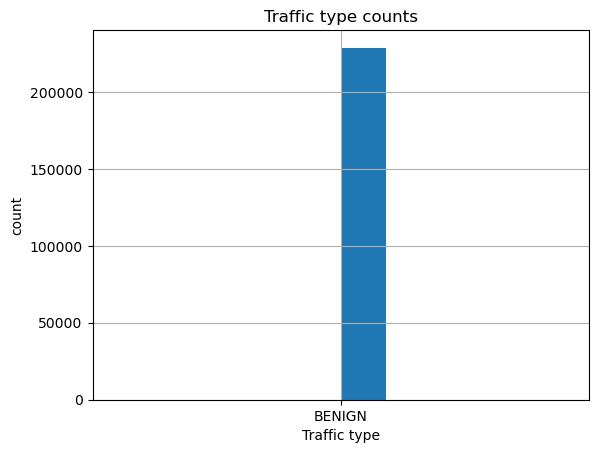

In [89]:
data[' Label'].hist()
plt.xlabel("Traffic type")
plt.ylabel("count")
plt.title("Traffic type counts")

<span style="color:green">I found that this particular dataset is imbalanced, however after I examine the data for Tuesday-Friday, this may not be the case, becuse we already knew that Monday's traffic was expected to be all benign. Overall I think the data is useable after cleaning and I had to drop some rows that had invalid results but I am hopefull that the Tuesday-Friday datasets will not be imbalanced like this one.</span>

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

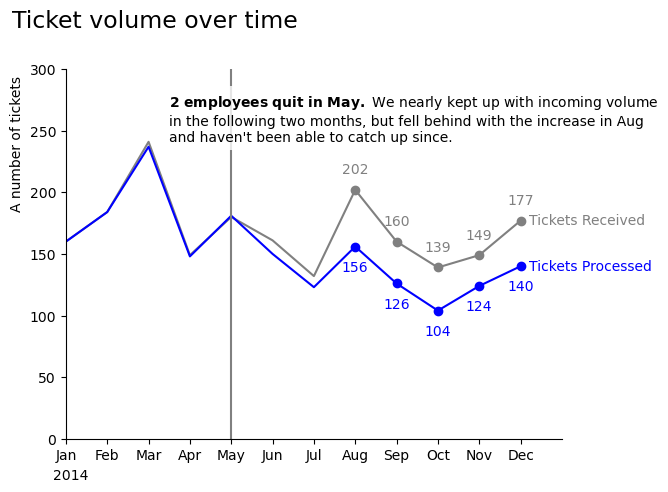

In [7]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
number_of_tickets_received = [160, 184, 241, 149, 180, 161, 132, 202, 160, 139, 149, 177]
number_of_tickets_processed = [160, 184, 237, 148, 181, 150, 123, 156, 126, 104, 124, 140]
plt.plot(months, number_of_tickets_received, color = "gray")
plt.plot(months, number_of_tickets_processed, color="blue")
plt.title("Ticket volume over time", fontsize=17, x = .18, pad = 30)
plt.ylabel("A number of tickets", y=.8) 
plt.ylim(bottom=0, top = 300)
plt.xlabel("2014", x=0.01) 
plt.margins(x=0)
plt.axvline(x = 4, color ='gray')
plt.text(2.5, 280, r"$\bf{2\ employees\ quit\ in\ May.}$ " "We nearly kept up with incoming volume\n" "in the following two months, but fell behind with the increase in Aug\n" "and haven't been able to catch up since.", ha= 'left', va = 'top', bbox=dict(facecolor='white', alpha =0.8, edgecolor='none'))
for i in range(7,12): 
    plt.text(i, number_of_tickets_received[i] + 13, str(number_of_tickets_received[i]), ha='center', color='grey') 
    plt.text(i, number_of_tickets_processed[i] - 20, str(number_of_tickets_processed[i]), ha='center', color='blue')
    plt.scatter(i, number_of_tickets_received[i], color='grey')
    plt.scatter(i, number_of_tickets_processed[i], color='blue')
plt.text(11.2, number_of_tickets_received[-1], "Tickets Received", color='grey', va='center') 
plt.text(11.2, number_of_tickets_processed[-1], "Tickets Processed", color='blue', va='center')
plt.xlim(right = 12)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()